# Frozen Historical Performance Tables

This notebook reads saved historical frozen-model tables generated by `scripts/export_frozen_historical_performance.py`.

Use it after refreshing the backing parquet:

```powershell
uv run python scripts/export_frozen_historical_performance.py
```

The notebook is intended for fast diagnostics and improvement hunting, not model recomputation.

Important:
- `performance` is the played-only table and should be used for Kaggle-faithful scoring questions.
- `all_matchups` contains the full seeded-pair universe with `was_played`, and should be used for coverage, bucket-mass, and exposure questions rather than realized scoring on unplayed games.

In [15]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

In [16]:
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PERFORMANCE_PATH = ROOT / "data" / "interim" / "frozen_historical_performance.parquet"
ALL_MATCHUPS_PATH = ROOT / "data" / "interim" / "frozen_historical_all_matchups.parquet"
MIN_GAMES_FOR_WORST_CELL_VIEW = 5
bucket_order = ["definite", "very_likely", "likely", "plausible", "remote"]

all_matchups = pd.read_parquet(ALL_MATCHUPS_PATH)
performance = pd.read_parquet(PERFORMANCE_PATH)
performance.head()

,Season,league,ID,LowTeamID,HighTeamID,was_played,outcome,Pred,play_prob,bucket,actual_round,actual_round_group,predicted_round,predicted_round_group,brier_component
0,2005,M,2005_1104_1454,1104,1454,True,0.0,0.836395,1.0,definite,1.0,R1,1,R1,0.699557
1,2005,M,2005_1112_1429,1112,1429,True,1.0,0.691065,1.0,definite,1.0,R1,1,R1,0.095441
2,2005,M,2005_1130_1335,1130,1335,True,1.0,0.814062,1.0,definite,1.0,R1,1,R1,0.034573
3,2005,M,2005_1137_1242,1137,1242,True,1.0,0.098467,1.0,definite,1.0,R1,1,R1,0.812761
4,2005,M,2005_1150_1301,1150,1301,True,0.0,0.637937,1.0,definite,1.0,R1,1,R1,0.406964


In [17]:
def summarize(frame: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    summary = (
        frame.groupby(group_cols, dropna=False)
        .agg(
            games=("ID", "size"),
            mean_pred=("Pred", "mean"),
            mean_outcome=("outcome", "mean"),
            mean_play_prob=("play_prob", "mean"),
            flat_brier=("brier_component", "mean"),
        )
        .reset_index()
    )
    for col in ["mean_pred", "mean_outcome", "mean_play_prob", "flat_brier"]:
        summary[col] = summary[col].round(6)
    return summary.sort_values(group_cols).reset_index(drop=True)


def summarize_all_matchups(frame: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    summary = (
        frame.groupby(group_cols, dropna=False)
        .agg(
            matchups=("ID", "size"),
            played_games=("was_played", "sum"),
            played_share=("was_played", "mean"),
            mean_pred=("Pred", "mean"),
            mean_play_prob=("play_prob", "mean"),
            total_play_prob_mass=("play_prob", "sum"),
        )
        .reset_index()
    )
    for col in ["played_share", "mean_pred", "mean_play_prob", "total_play_prob_mass"]:
        summary[col] = summary[col].round(6)
    return summary.sort_values(group_cols).reset_index(drop=True)


combined_by_season = summarize(performance, ["Season"])
by_season_and_league = summarize(performance, ["Season", "league"])
by_round = summarize(performance, ["Season", "league", "actual_round"])
by_round_group = summarize(performance, ["Season", "league", "actual_round_group"])
by_bucket = summarize(performance, ["Season", "league", "bucket"])
by_round_and_bucket = summarize(performance, ["Season", "league", "actual_round", "bucket"])
cross_season_round_bucket = summarize(performance, ["league", "actual_round", "bucket"])
all_matchups_by_season = summarize_all_matchups(all_matchups, ["Season"])
all_matchups_by_season_and_league = summarize_all_matchups(all_matchups, ["Season", "league"])
all_matchups_by_bucket = summarize_all_matchups(all_matchups, ["Season", "league", "bucket"])
all_matchups_cross_season_bucket = summarize_all_matchups(all_matchups, ["league", "bucket"])
worst_cells = (
    by_round_and_bucket.loc[by_round_and_bucket["games"] >= MIN_GAMES_FOR_WORST_CELL_VIEW]
    .sort_values(["flat_brier", "games"], ascending=[False, False])
    .reset_index(drop=True)
)

In [18]:
print("Combined Men + Women by Season")
display(combined_by_season)

print("By Season and League")
display(by_season_and_league)

print("By Season, League, and Actual Round")
display(by_round)

print("By Season, League, and Actual Round Group")
display(by_round_group)

print("By Season, League, and Occurrence Likelihood Bucket")
display(
    by_bucket.assign(
        bucket=lambda df: pd.Categorical(df["bucket"], categories=bucket_order, ordered=True)
    ).sort_values(["Season", "league", "bucket"])
)

print("By Season, League, Actual Round, and Occurrence Likelihood Bucket")
display(
    by_round_and_bucket.assign(
        bucket=lambda df: pd.Categorical(df["bucket"], categories=bucket_order, ordered=True)
    ).sort_values(["Season", "league", "actual_round", "bucket"])
)

Combined Men + Women by Season


,Season,games,mean_pred,mean_outcome,mean_play_prob,flat_brier
0,2005,63,0.542973,0.492063,0.655462,0.182294
1,2006,63,0.494979,0.507937,0.623448,0.199665
2,2007,63,0.514365,0.476190,0.648050,0.158885
3,2008,63,0.469146,0.460317,0.665064,0.159659
4,2009,63,0.476948,0.380952,0.643685,0.172821
5,2010,63,0.501264,0.492063,0.628133,0.185271
6,2011,126,0.563254,0.531746,0.662397,0.196570
7,2012,126,0.532803,0.523810,0.673744,0.148203
8,2013,126,0.522643,0.571429,0.668038,0.178212
9,2014,126,0.470720,0.515873,0.670019,0.169397


By Season and League


,Season,league,games,mean_pred,mean_outcome,mean_play_prob,flat_brier
0,2005,M,63,0.542973,0.492063,0.655462,0.182294
1,2006,M,63,0.494979,0.507937,0.623448,0.199665
2,2007,M,63,0.514365,0.476190,0.648050,0.158885
3,2008,M,63,0.469146,0.460317,0.665064,0.159659
4,2009,M,63,0.476948,0.380952,0.643685,0.172821
5,2010,M,63,0.501264,0.492063,0.628133,0.185271
6,2011,M,63,0.488572,0.587302,0.616919,0.212276
7,2011,W,63,0.637935,0.476190,0.707876,0.180863
8,2012,M,63,0.517789,0.539683,0.603406,0.180476
9,2012,W,63,0.547817,0.507937,0.744082,0.115930


By Season, League, and Actual Round


...

,Season,league,actual_round_group,games,mean_pred,mean_outcome,mean_play_prob,flat_brier
0,2005,M,R1,32,0.514419,0.562500,0.992843,0.164305
1,2005,M,R2+,31,0.572448,0.419355,0.307199,0.200864
2,2006,M,R1,32,0.469945,0.468750,0.985675,0.186305
3,2006,M,R2+,31,0.520822,0.548387,0.249536,0.213457
4,2007,M,R1,32,0.482066,0.281250,0.987764,0.145124
...,...,...,...,...,...,...,...,...
63,2024,W,R2+,31,0.433398,0.483871,0.494113,0.133499
64,2025,M,R1,32,0.533573,0.625000,0.940943,0.112829
65,2025,M,R2+,31,0.499103,0.548387,0.407281,0.156546
66,2025,W,R1,32,0.556941,0.500000,0.938715,0.085177


By Season, League, and Occurrence Likelihood Bucket


,Season,league,bucket,games,mean_pred,mean_outcome,mean_play_prob,flat_brier
0,2005,M,definite,31,0.500381,0.548387,1.000000,0.169523
4,2005,M,very_likely,16,0.560514,0.437500,0.532836,0.195730
1,2005,M,likely,6,0.583380,0.500000,0.219560,0.239629
2,2005,M,plausible,8,0.602253,0.375000,0.051868,0.170274
3,2005,M,remote,2,0.704482,0.500000,0.018223,0.148843
...,...,...,...,...,...,...,...,...
155,2025,M,plausible,2,0.556681,1.000000,0.081284,0.260676
156,2025,M,remote,1,0.140869,0.000000,0.024244,0.019844
158,2025,W,definite,28,0.581868,0.535714,1.000000,0.092301
160,2025,W,very_likely,30,0.414332,0.333333,0.560571,0.112525


By Season, League, Actual Round, and Occurrence Likelihood Bucket


,Season,league,actual_round,bucket,games,mean_pred,mean_outcome,mean_play_prob,flat_brier
0,2005,M,1.0,definite,31,0.500381,0.548387,1.000000,0.169523
1,2005,M,1.0,very_likely,1,0.949606,1.000000,0.770970,0.002540
4,2005,M,2.0,very_likely,11,0.485766,0.272727,0.577984,0.179249
2,2005,M,2.0,likely,4,0.743953,0.500000,0.227269,0.260130
3,2005,M,2.0,plausible,1,0.157492,0.000000,0.036331,0.024804
...,...,...,...,...,...,...,...,...,...
410,2025,W,4.0,very_likely,2,0.447270,0.500000,0.576777,0.150656
409,2025,W,4.0,likely,2,0.329704,0.000000,0.287870,0.108705
412,2025,W,5.0,very_likely,1,0.624942,1.000000,0.310564,0.140669
411,2025,W,5.0,likely,1,0.553917,1.000000,0.230363,0.198990


In [19]:
print("Cross-season round/bucket view")
display(
    cross_season_round_bucket.assign(
        bucket=lambda df: pd.Categorical(df["bucket"], categories=bucket_order, ordered=True)
    ).sort_values(["league", "actual_round", "bucket"])
)

print("Worst round/bucket cells with at least", MIN_GAMES_FOR_WORST_CELL_VIEW, "games")
display(worst_cells)

print("Pivoted flat Brier by Round and Bucket")
pivot = (
    by_round_and_bucket.assign(
        bucket=lambda df: pd.Categorical(df["bucket"], categories=bucket_order, ordered=True)
    )
    .pivot_table(
        index=["Season", "league", "actual_round"],
        columns="bucket",
        values="flat_brier",
        observed=False,
    )
    .reset_index()
)
display(pivot)

Cross-season round/bucket view


,league,actual_round,bucket,games,mean_pred,mean_outcome,mean_play_prob,flat_brier
0,M,1.0,definite,577,0.496644,0.485269,1.000000,0.173440
2,M,1.0,very_likely,61,0.534481,0.475410,0.534307,0.130875
1,M,1.0,likely,1,0.026811,0.000000,0.293331,0.000719
6,M,2.0,very_likely,243,0.507510,0.506173,0.499921,0.181008
3,M,2.0,likely,56,0.509129,0.517857,0.201357,0.154538
4,M,2.0,plausible,18,0.431021,0.277778,0.057620,0.225423
5,M,2.0,remote,3,0.610568,0.666667,0.009269,0.015223
10,M,3.0,very_likely,52,0.518826,0.576923,0.383503,0.207981
7,M,3.0,likely,68,0.553303,0.617647,0.203147,0.196064
8,M,3.0,plausible,29,0.574537,0.620690,0.065781,0.217644


Worst round/bucket cells with at least 5 games


,Season,league,actual_round,bucket,games,mean_pred,mean_outcome,mean_play_prob,flat_brier
0,2011,W,2.0,very_likely,12,0.528299,0.333333,0.644207,0.334658
1,2022,W,2.0,likely,6,0.520192,0.500000,0.202185,0.288085
2,2016,W,2.0,very_likely,11,0.588811,0.454545,0.671166,0.261844
3,2018,M,2.0,very_likely,12,0.517554,0.416667,0.509986,0.256715
4,2010,M,3.0,likely,6,0.560477,0.666667,0.198645,0.230673
...,...,...,...,...,...,...,...,...,...
85,2015,W,3.0,very_likely,6,0.594681,0.500000,0.548058,0.059864
86,2019,M,2.0,likely,5,0.535019,0.600000,0.197548,0.047952
87,2012,W,3.0,very_likely,6,0.694310,0.833333,0.470172,0.045569
88,2019,W,3.0,very_likely,5,0.672556,0.800000,0.488471,0.042977


Pivoted flat Brier by Round and Bucket


bucket,Season,league,actual_round,definite,very_likely,likely,plausible,remote
0,2005,M,1.0,0.169523,0.002540,NaN,NaN,NaN
1,2005,M,2.0,NaN,0.179249,0.260130,0.024804,NaN
2,2005,M,3.0,NaN,0.289353,NaN,0.104402,NaN
3,2005,M,4.0,NaN,NaN,0.019373,0.323351,0.015049
4,2005,M,5.0,NaN,NaN,0.377879,NaN,0.282638
...,...,...,...,...,...,...,...,...
199,2025,W,2.0,NaN,0.126295,NaN,NaN,NaN
200,2025,W,3.0,NaN,0.110256,0.013757,NaN,NaN
201,2025,W,4.0,NaN,0.150656,0.108705,NaN,NaN
202,2025,W,5.0,NaN,0.140669,0.198990,NaN,NaN


In [20]:
def plot_heatmap_grid(
    frame: pd.DataFrame,
    *,
    row_col: str,
    col_col: str,
    value_col: str,
    title_prefix: str,
    col_order: list | None = None,
    cmap: str = "YlOrRd",
) -> None:
    leagues = sorted(frame["league"].dropna().unique().tolist())
    fig, axes = plt.subplots(1, len(leagues), figsize=(7 * len(leagues), 6), squeeze=False)
    for axis, league in zip(axes[0], leagues, strict=False):
        league_frame = frame.loc[frame["league"] == league].copy()
        pivot = league_frame.pivot_table(
            index=row_col,
            columns=col_col,
            values=value_col,
            observed=False,
        )
        if col_order is not None:
            pivot = pivot.reindex(columns=col_order)
        image = axis.imshow(pivot.to_numpy(), aspect="auto", cmap=cmap)
        axis.set_title(f"{title_prefix} — {league}")
        axis.set_xlabel(col_col)
        axis.set_ylabel(row_col)
        axis.set_xticks(range(len(pivot.columns)))
        axis.set_xticklabels([str(value) for value in pivot.columns], rotation=45, ha="right")
        axis.set_yticks(range(len(pivot.index)))
        axis.set_yticklabels([str(value) for value in pivot.index])
        for row_index, row_value in enumerate(pivot.index):
            for col_index, col_value in enumerate(pivot.columns):
                value = pivot.loc[row_value, col_value]
                if pd.notna(value):
                    axis.text(
                        col_index,
                        row_index,
                        f"{value:.3f}",
                        ha="center",
                        va="center",
                        fontsize=8,
                    )
        fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def bucket_diagnostics(frame: pd.DataFrame) -> pd.DataFrame:
    summary = (
        frame.groupby(["league", "bucket"], dropna=False)
        .agg(
            games=("ID", "size"),
            mean_pred=("Pred", "mean"),
            mean_outcome=("outcome", "mean"),
            mean_play_prob=("play_prob", "mean"),
            flat_brier=("brier_component", "mean"),
            total_brier=("brier_component", "sum"),
        )
        .reset_index()
    )
    return summary.assign(
        bucket=lambda df: pd.Categorical(df["bucket"], categories=bucket_order, ordered=True)
    ).sort_values(["league", "bucket"])


bucket_diag = bucket_diagnostics(performance)

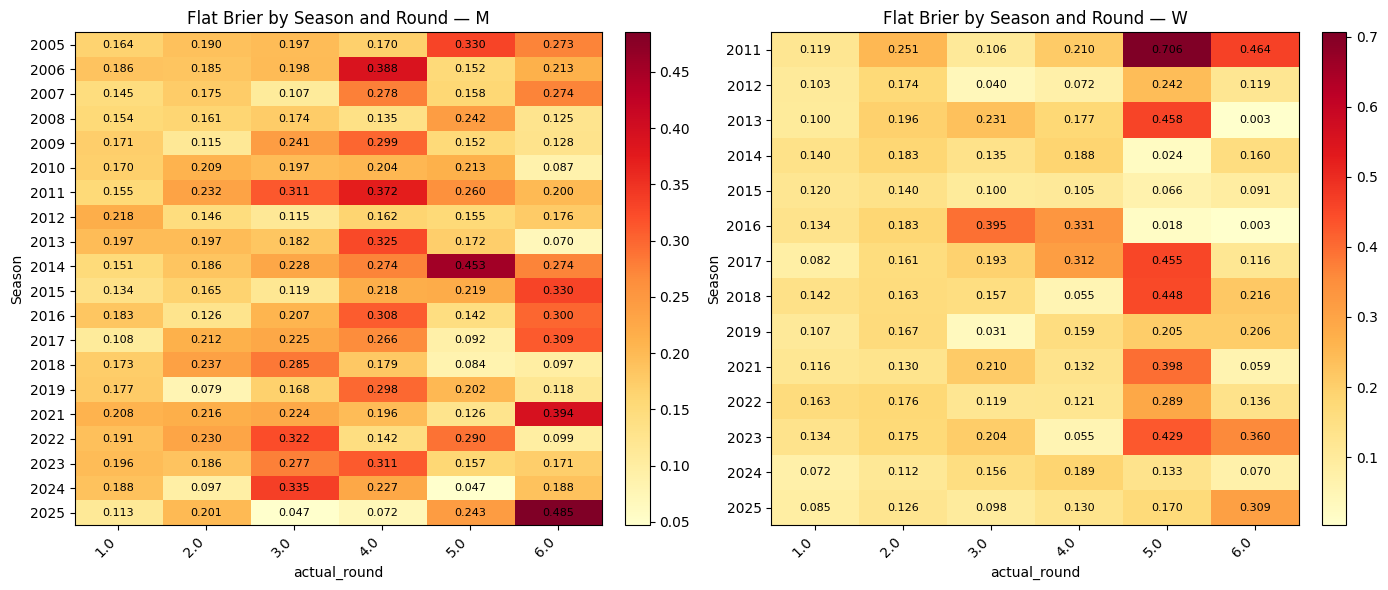

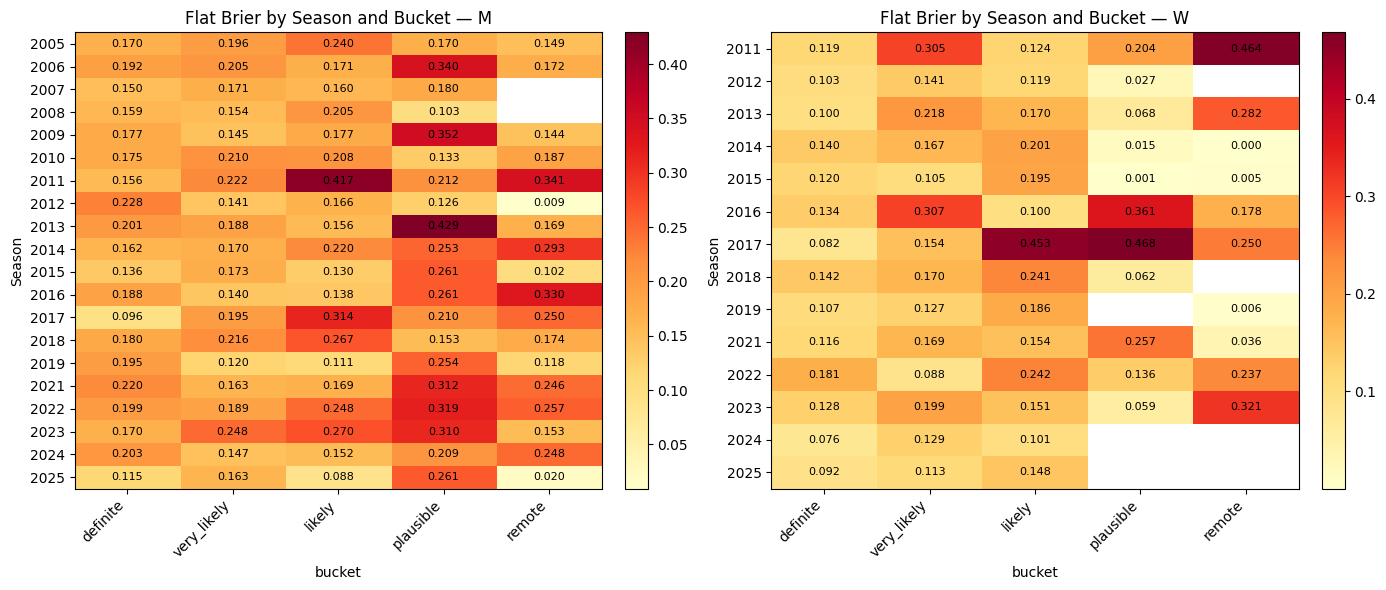

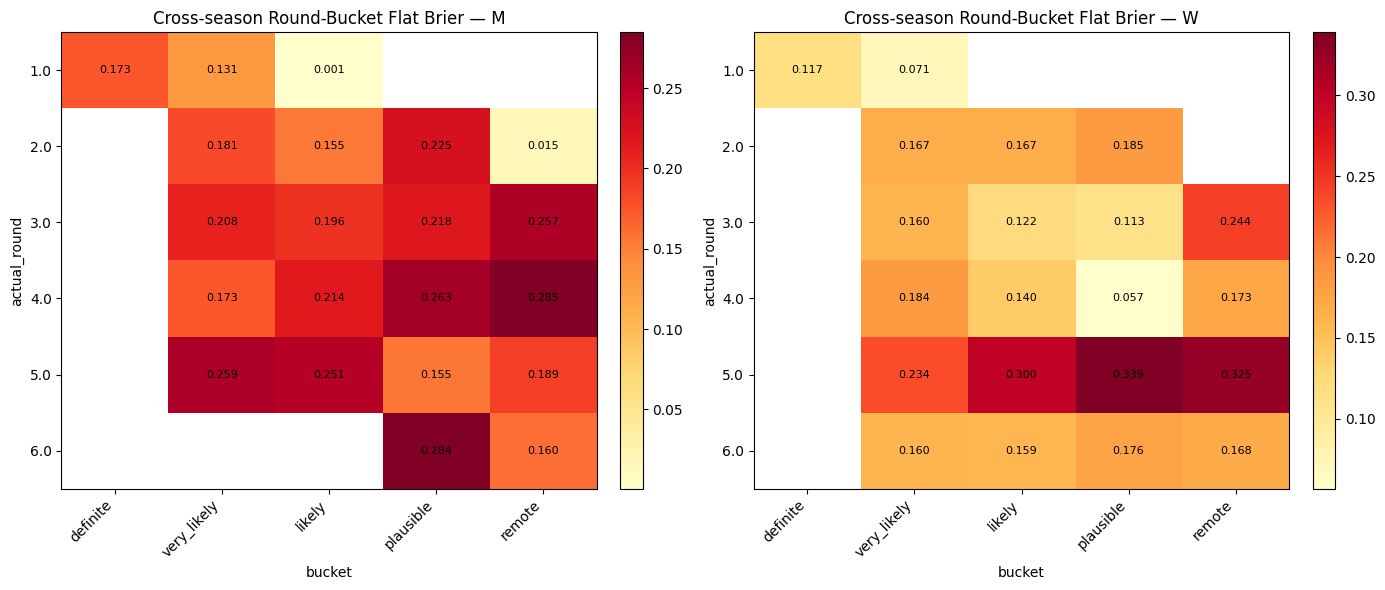

In [21]:
plot_heatmap_grid(
    by_round,
    row_col="Season",
    col_col="actual_round",
    value_col="flat_brier",
    title_prefix="Flat Brier by Season and Round",
)

plot_heatmap_grid(
    by_bucket.assign(
        bucket=lambda df: pd.Categorical(df["bucket"], categories=bucket_order, ordered=True)
    ),
    row_col="Season",
    col_col="bucket",
    value_col="flat_brier",
    title_prefix="Flat Brier by Season and Bucket",
    col_order=bucket_order,
)

plot_heatmap_grid(
    cross_season_round_bucket.assign(
        bucket=lambda df: pd.Categorical(df["bucket"], categories=bucket_order, ordered=True)
    ),
    row_col="actual_round",
    col_col="bucket",
    value_col="flat_brier",
    title_prefix="Cross-season Round-Bucket Flat Brier",
    col_order=bucket_order,
)

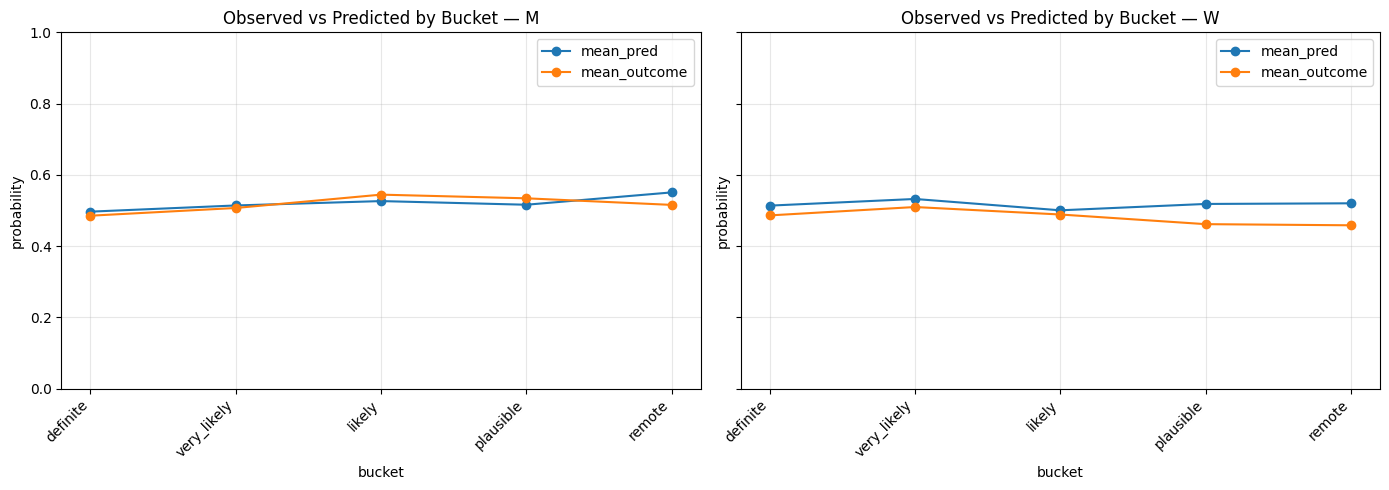

,league,bucket,games,mean_pred,mean_outcome,mean_play_prob,flat_brier,total_brier
0,M,definite,577,0.496644,0.485269,1.000000,0.173440,100.074793
4,M,very_likely,361,0.513998,0.506925,0.486771,0.176552,63.735364
1,M,likely,169,0.526296,0.544379,0.198085,0.187582,31.701406
2,M,plausible,88,0.516052,0.534091,0.060798,0.230119,20.250494
3,M,remote,64,0.550654,0.515625,0.011846,0.214148,13.705489
5,W,definite,432,0.513561,0.486111,1.000000,0.117087,50.581789
9,W,very_likely,312,0.532227,0.509615,0.579783,0.163696,51.073173
6,W,likely,88,0.500392,0.488636,0.210652,0.172559,15.185164
7,W,plausible,26,0.518256,0.461538,0.067344,0.153265,3.984877
8,W,remote,24,0.520077,0.458333,0.012357,0.210841,5.060187


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, league in zip(axes, sorted(bucket_diag["league"].unique().tolist()), strict=False):
    league_frame = bucket_diag.loc[bucket_diag["league"] == league]
    x_positions = range(len(league_frame))
    axis.plot(x_positions, league_frame["mean_pred"], marker="o", label="mean_pred")
    axis.plot(x_positions, league_frame["mean_outcome"], marker="o", label="mean_outcome")
    axis.set_xticks(list(x_positions))
    axis.set_xticklabels([str(value) for value in league_frame["bucket"]], rotation=45, ha="right")
    axis.set_ylim(0, 1)
    axis.set_title(f"Observed vs Predicted by Bucket — {league}")
    axis.set_xlabel("bucket")
    axis.set_ylabel("probability")
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

display(bucket_diag)

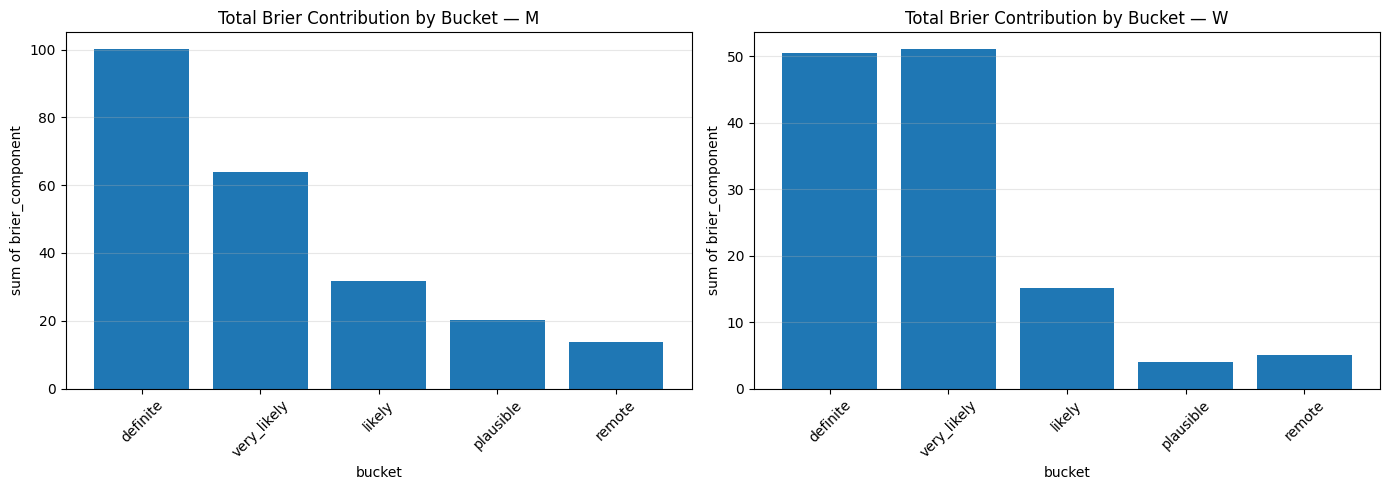

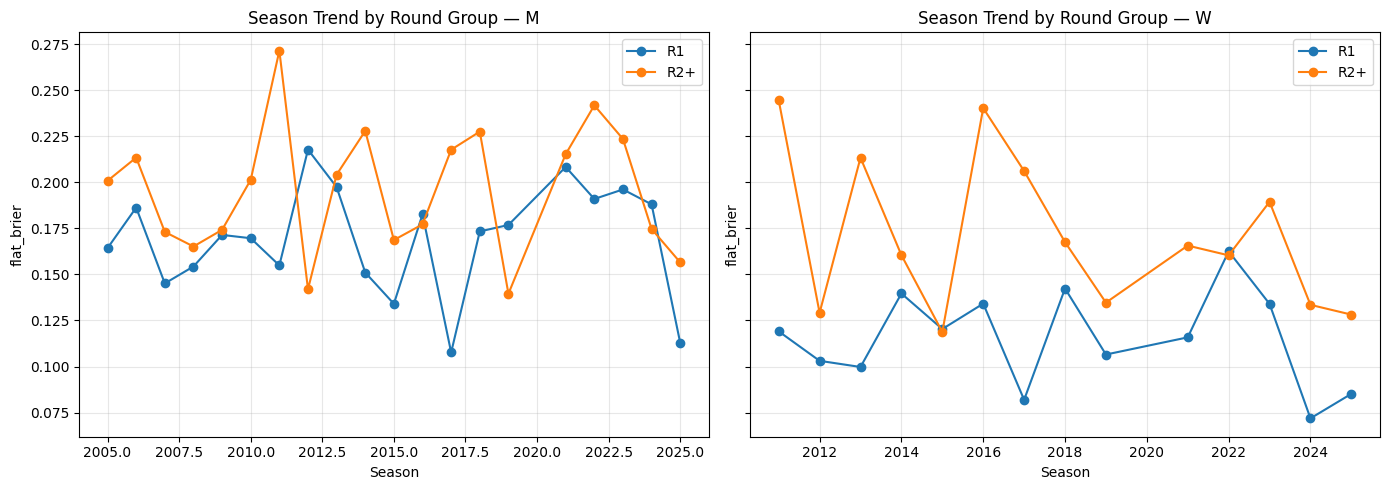

,Season,league,actual_round,bucket,games,mean_pred,mean_outcome,mean_play_prob,flat_brier
0,2011,W,2.0,very_likely,12,0.528299,0.333333,0.644207,0.334658
1,2022,W,2.0,likely,6,0.520192,0.500000,0.202185,0.288085
2,2016,W,2.0,very_likely,11,0.588811,0.454545,0.671166,0.261844
3,2018,M,2.0,very_likely,12,0.517554,0.416667,0.509986,0.256715
4,2010,M,3.0,likely,6,0.560477,0.666667,0.198645,0.230673
...,...,...,...,...,...,...,...,...,...
85,2015,W,3.0,very_likely,6,0.594681,0.500000,0.548058,0.059864
86,2019,M,2.0,likely,5,0.535019,0.600000,0.197548,0.047952
87,2012,W,3.0,very_likely,6,0.694310,0.833333,0.470172,0.045569
88,2019,W,3.0,very_likely,5,0.672556,0.800000,0.488471,0.042977


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for axis, league in zip(axes, sorted(bucket_diag["league"].unique().tolist()), strict=False):
    league_frame = bucket_diag.loc[bucket_diag["league"] == league]
    axis.bar([str(value) for value in league_frame["bucket"]], league_frame["total_brier"])
    axis.set_title(f"Total Brier Contribution by Bucket — {league}")
    axis.set_xlabel("bucket")
    axis.set_ylabel("sum of brier_component")
    axis.tick_params(axis="x", rotation=45)
    axis.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, league in zip(axes, sorted(by_round_group["league"].unique().tolist()), strict=False):
    league_frame = by_round_group.loc[by_round_group["league"] == league]
    for round_group in ["R1", "R2+"]:
        round_frame = league_frame.loc[league_frame["actual_round_group"] == round_group]
        axis.plot(round_frame["Season"], round_frame["flat_brier"], marker="o", label=round_group)
    axis.set_title(f"Season Trend by Round Group — {league}")
    axis.set_xlabel("Season")
    axis.set_ylabel("flat_brier")
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

display(worst_cells)

In [24]:
print("All-matchups overview by season")
display(all_matchups_by_season)

print("All-matchups overview by season and league")
display(all_matchups_by_season_and_league)

print("All-matchups by season, league, and bucket")
display(
    all_matchups_by_bucket.assign(
        bucket=lambda df: pd.Categorical(df["bucket"], categories=bucket_order, ordered=True)
    ).sort_values(["Season", "league", "bucket"])
)

print("Cross-season all-matchups bucket exposure")
display(
    all_matchups_cross_season_bucket.assign(
        bucket=lambda df: pd.Categorical(df["bucket"], categories=bucket_order, ordered=True)
    ).sort_values(["league", "bucket"])
)

All-matchups overview by season


,Season,matchups,played_games,played_share,mean_pred,mean_play_prob,total_play_prob_mass
0,2005,2080,63,0.030288,0.495112,0.030769,64.0
1,2006,2080,63,0.030288,0.501357,0.030769,64.0
2,2007,2080,63,0.030288,0.491847,0.030769,64.0
3,2008,2080,63,0.030288,0.472529,0.030769,64.0
4,2009,2080,63,0.030288,0.465854,0.030769,64.0
5,2010,2080,63,0.030288,0.511440,0.030769,64.0
6,2011,4294,126,0.029343,0.559433,0.030275,130.0
7,2012,4294,126,0.029343,0.524705,0.030275,130.0
8,2013,4294,126,0.029343,0.522687,0.030275,130.0
9,2014,4294,126,0.029343,0.522519,0.030275,130.0


All-matchups overview by season and league


,Season,league,matchups,played_games,played_share,mean_pred,mean_play_prob,total_play_prob_mass
0,2005,M,2080,63,0.030288,0.495112,0.030769,64.0
1,2006,M,2080,63,0.030288,0.501357,0.030769,64.0
2,2007,M,2080,63,0.030288,0.491847,0.030769,64.0
3,2008,M,2080,63,0.030288,0.472529,0.030769,64.0
4,2009,M,2080,63,0.030288,0.465854,0.030769,64.0
5,2010,M,2080,63,0.030288,0.511440,0.030769,64.0
6,2011,M,2278,63,0.027656,0.474542,0.029412,67.0
7,2011,W,2016,63,0.031250,0.655357,0.031250,63.0
8,2012,M,2278,63,0.027656,0.509419,0.029412,67.0
9,2012,W,2016,63,0.031250,0.541976,0.031250,63.0


All-matchups by season, league, and bucket


,Season,league,bucket,matchups,played_games,played_share,mean_pred,mean_play_prob,total_play_prob_mass
0,2005,M,definite,32,31,0.968750,0.491901,1.000000,32.000000
4,2005,M,very_likely,38,16,0.421053,0.523259,0.479687,18.228104
1,2005,M,likely,35,6,0.171429,0.592313,0.175344,6.137057
2,2005,M,plausible,87,8,0.091954,0.516372,0.053648,4.667377
3,2005,M,remote,1888,2,0.001059,0.491818,0.001572,2.967463
...,...,...,...,...,...,...,...,...,...
165,2025,W,definite,32,28,0.875000,0.577072,1.000000,32.000000
169,2025,W,very_likely,48,30,0.625000,0.417284,0.537509,25.800411
166,2025,W,likely,29,5,0.172414,0.425329,0.168409,4.883850
167,2025,W,plausible,43,0,0.000000,0.464365,0.054999,2.364967


Cross-season all-matchups bucket exposure


,league,bucket,matchups,played_games,played_share,mean_pred,mean_play_prob,total_play_prob_mass
0,M,definite,640,577,0.901562,0.495408,1.000000,640.000000
4,M,very_likely,773,361,0.467012,0.524288,0.464305,358.907683
1,M,likely,836,169,0.202153,0.517893,0.175931,147.078046
2,M,plausible,1837,88,0.047904,0.514143,0.055372,101.719022
3,M,remote,40286,64,0.001589,0.499531,0.001844,74.295248
5,W,definite,448,432,0.964286,0.514913,1.000000,448.000000
9,W,very_likely,590,312,0.528814,0.539684,0.545413,321.793548
6,W,likely,381,88,0.230971,0.518660,0.186341,70.996064
7,W,plausible,608,26,0.042763,0.521815,0.053751,32.680539
8,W,remote,27245,24,0.000881,0.529406,0.000900,24.529848
